## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

# Task 1 – Data Preparation & EDA (Clustering)

### Part A – Data Loading & Initial Exploration

In [2]:
# Load dataset
df = pd.read_csv("customer_data.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())

# For clustering, we will **not** use the target column 'Churned' (unsupervised)
if "Churned" in df.columns:
    print("\nChurned distribution (for later analysis, not used in clustering):")
    print(df["Churned"].value_counts(normalize=True))

Shape: (1000, 31)

Columns: ['Customer_ID', 'Age', 'Gender', 'Annual_Income', 'Education', 'Location_Type', 'Account_Age_Days', 'Membership_Type', 'Payment_Method', 'Total_Purchases', 'Total_Amount_Spent', 'Avg_Order_Value', 'Days_Since_Last_Purchase', 'Purchase_Frequency', 'Visits_Per_Month', 'Time_Per_Visit_Minutes', 'Product_Views_Per_Visit', 'Cart_Abandonment_Rate', 'Email_Open_Rate', 'Customer_Service_Contacts', 'Satisfaction_Score', 'NPS', 'Referrals', 'Loyalty_Points', 'Complaints', 'Favorite_Category', 'Num_Categories_Shopped', 'Discount_Usage_Rate', 'Returns_Rate', 'Churn_Risk_Score', 'Churned']

Data types:
Customer_ID                   object
Age                            int64
Gender                        object
Annual_Income                  int64
Education                     object
Location_Type                 object
Account_Age_Days               int64
Membership_Type               object
Payment_Method                object
Total_Purchases                int64
Total

### Part B – Exploratory Data Analysis

Numeric columns: ['Age', 'Annual_Income', 'Account_Age_Days', 'Total_Purchases', 'Total_Amount_Spent', 'Avg_Order_Value', 'Days_Since_Last_Purchase', 'Purchase_Frequency', 'Visits_Per_Month', 'Time_Per_Visit_Minutes', 'Product_Views_Per_Visit', 'Cart_Abandonment_Rate', 'Email_Open_Rate', 'Customer_Service_Contacts', 'Satisfaction_Score', 'NPS', 'Referrals', 'Loyalty_Points', 'Complaints', 'Num_Categories_Shopped', 'Discount_Usage_Rate', 'Returns_Rate', 'Churn_Risk_Score', 'Churned']
Categorical columns: ['Customer_ID', 'Gender', 'Education', 'Location_Type', 'Membership_Type', 'Payment_Method', 'Favorite_Category']


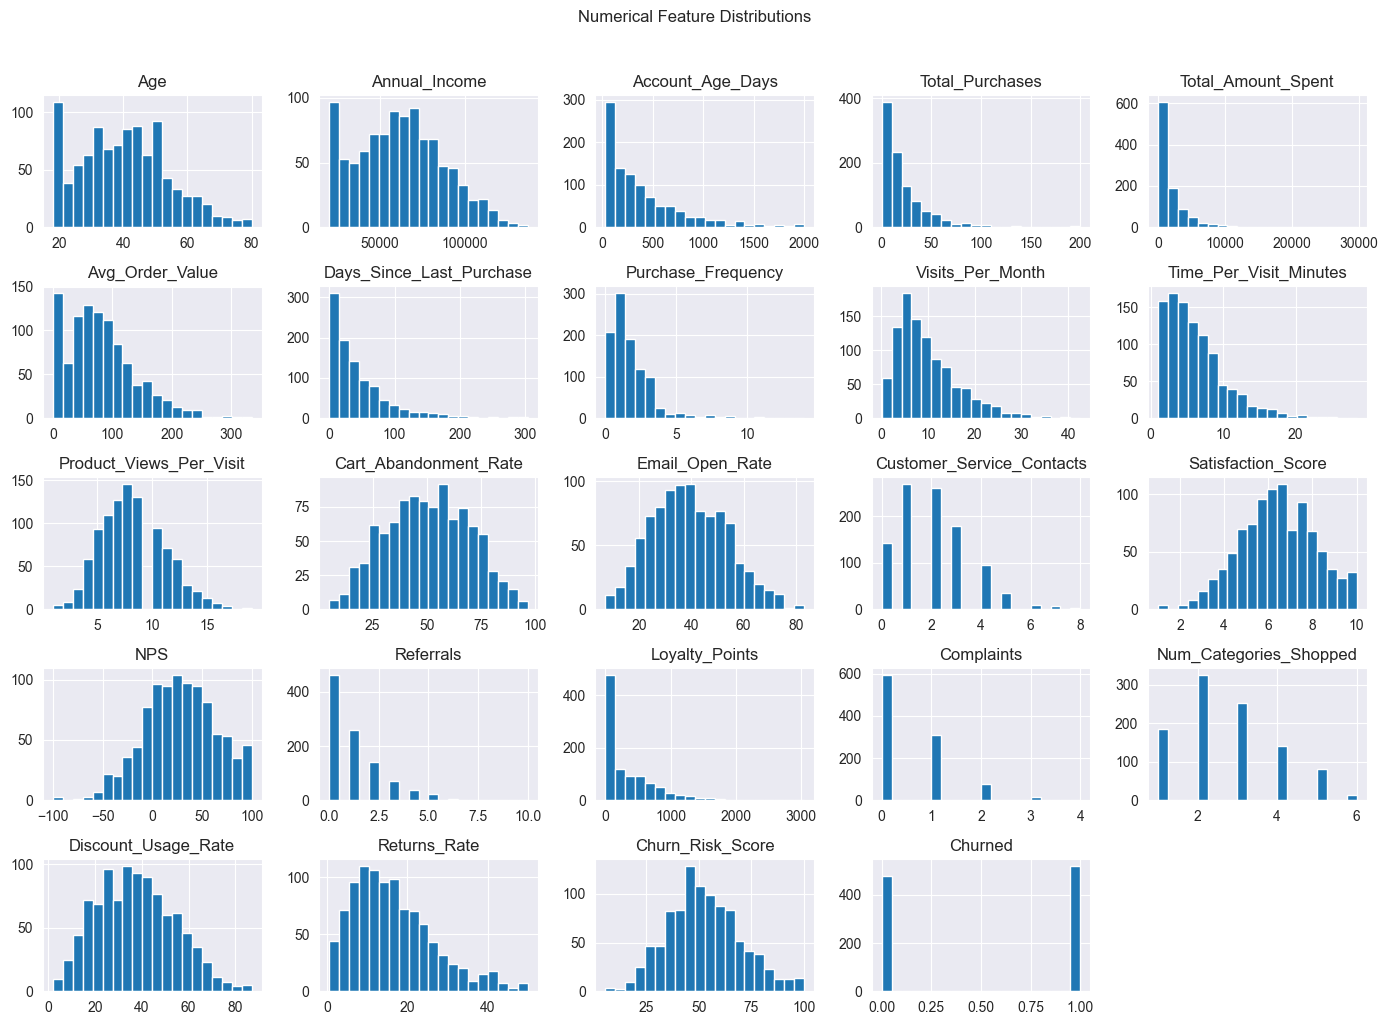

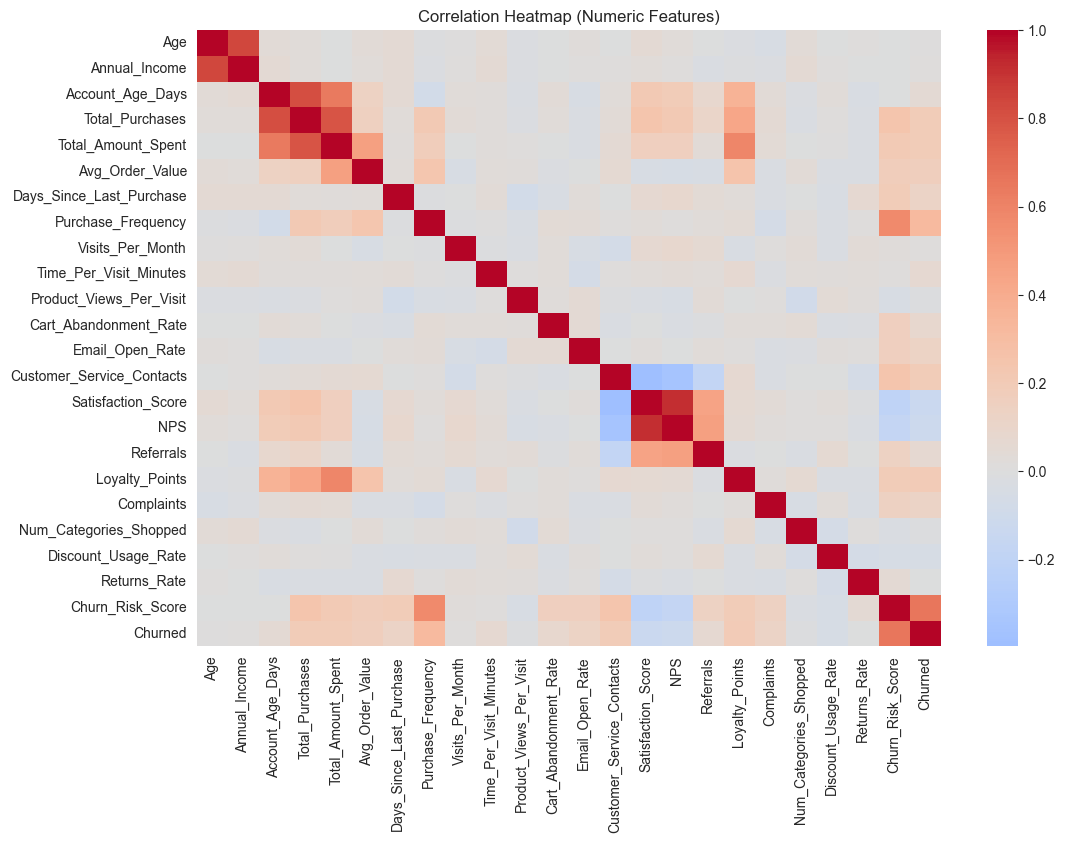

In [3]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Histograms
df[numeric_cols].hist(bins=20, figsize=(14, 10))
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

# Correlation heatmap
corr = df[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

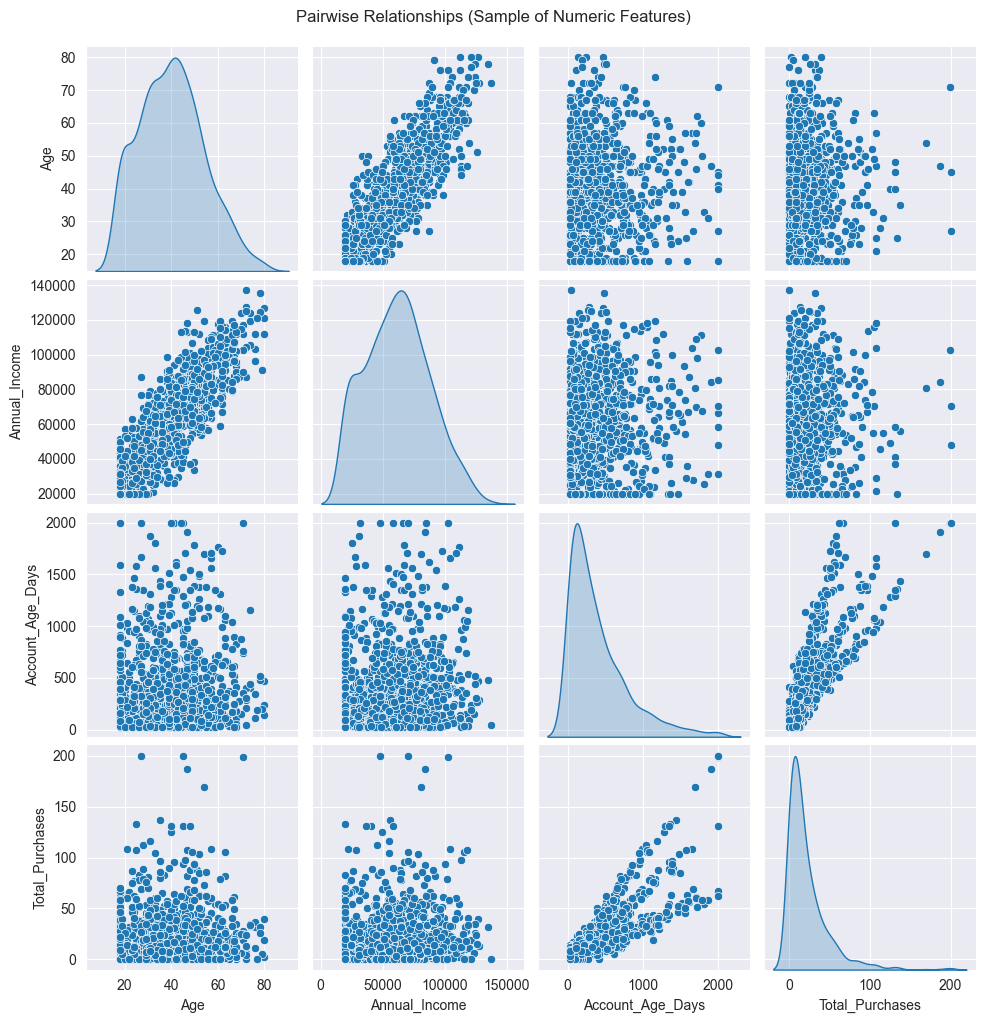

In [4]:
# Some scatter plots to see potential groupings (using a few numeric features)
selected = numeric_cols[:4]  # choose first 4 numeric columns
if len(selected) >= 2:
    sns.pairplot(df, vars=selected, diag_kind='kde')
    plt.suptitle("Pairwise Relationships (Sample of Numeric Features)", y=1.02)
    plt.show()

### Key EDA Insights (Fill in Your Observations)

- List any visible clusters or patterns in the numeric features.  
- Note any skew or outliers that might affect clustering.  
- Comment on which features seem most useful for segmentation.  


### Part C – Data Preprocessing for Clustering

In [5]:
df_processed = df.copy()

# 1. Handle missing values: numeric -> median, categorical -> mode
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()

for col in numeric_cols:
    median_value = df_processed[col].median()
    df_processed[col].fillna(median_value, inplace=True)

for col in categorical_cols:
    mode_value = df_processed[col].mode().iloc[0]
    df_processed[col].fillna(mode_value, inplace=True)

print("Missing values after imputation:")
print(df_processed.isna().sum())

# 2. Remove ID and leakage columns
cols_to_drop = []
if "Customer_ID" in df_processed.columns:
    cols_to_drop.append("Customer_ID")
if "Churn_Risk_Score" in df_processed.columns:
    cols_to_drop.append("Churn_Risk_Score")
if "Churned" in df_processed.columns:
    cols_to_drop.append("Churned")

df_processed = df_processed.drop(columns=cols_to_drop)
print("Dropped columns (ID / leakage / label):", cols_to_drop)

# 3. One-hot encode categorical features
df_encoded = pd.get_dummies(df_processed, drop_first=True)
print("Shape after encoding:", df_encoded.shape)

# 4. Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

Missing values after imputation:
Customer_ID                  0
Age                          0
Gender                       0
Annual_Income                0
Education                    0
Location_Type                0
Account_Age_Days             0
Membership_Type              0
Payment_Method               0
Total_Purchases              0
Total_Amount_Spent           0
Avg_Order_Value              0
Days_Since_Last_Purchase     0
Purchase_Frequency           0
Visits_Per_Month             0
Time_Per_Visit_Minutes       0
Product_Views_Per_Visit      0
Cart_Abandonment_Rate        0
Email_Open_Rate              0
Customer_Service_Contacts    0
Satisfaction_Score           0
NPS                          0
Referrals                    0
Loyalty_Points               0
Complaints                   0
Favorite_Category            0
Num_Categories_Shopped       0
Discount_Usage_Rate          0
Returns_Rate                 0
Churn_Risk_Score             0
Churned                      0
dtype:

# Task 2 – Model Implementation (Clustering)

### Part B1 – K-Means Clustering & Validation

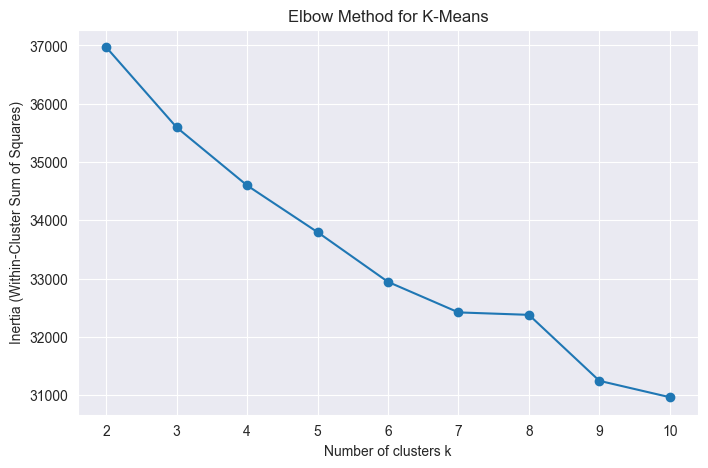

In [6]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure()
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for K-Means")
plt.xticks(k_values)
plt.show()

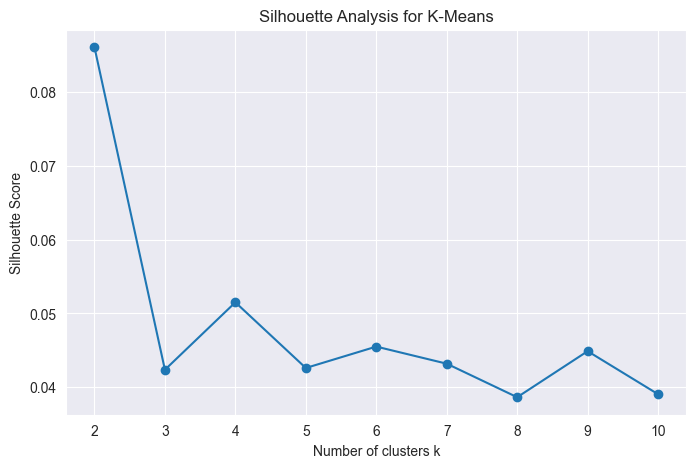

Best k by silhouette score: 2


In [7]:
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.figure()
plt.plot(k_values, sil_scores, marker='o')
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for K-Means")
plt.xticks(k_values)
plt.show()

best_k = k_values[int(np.argmax(sil_scores))]
print("Best k by silhouette score:", best_k)

In [8]:
# Train final K-Means with the chosen k
optimal_k = best_k  # you can override manually if needed (e.g., 3–5)
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)

df_clusters = df.copy()
df_clusters['Cluster'] = cluster_labels
df_clusters.head()

,Customer_ID,Age,Gender,Annual_Income,Education,Location_Type,Account_Age_Days,Membership_Type,Payment_Method,Total_Purchases,...,Referrals,Loyalty_Points,Complaints,Favorite_Category,Num_Categories_Shopped,Discount_Usage_Rate,Returns_Rate,Churn_Risk_Score,Churned,Cluster
0,CUST0001,47,Male,68822,High School,Urban,62,Premium,PayPal,9,...,0,613,0,Sports,3,37.6,28.7,73.4,1,1
1,CUST0002,37,Male,46578,Bachelor,Suburban,838,VIP,Credit Card,83,...,1,1317,1,Electronics,1,21.1,16.7,59.3,1,0
2,CUST0003,49,Female,81128,Bachelor,Urban,300,Basic,Debit Card,18,...,0,153,1,Books,1,66.5,10.3,44.3,0,1
3,CUST0004,62,Female,113217,High School,Urban,251,Premium,Credit Card,21,...,0,1019,1,Beauty,2,27.2,14.2,55.8,1,1
4,CUST0005,36,Male,28062,High School,Urban,45,Basic,Credit Card,4,...,1,658,1,Sports,3,55.5,17.5,80.6,1,1


### Part B2 – Alternative Clustering Methods

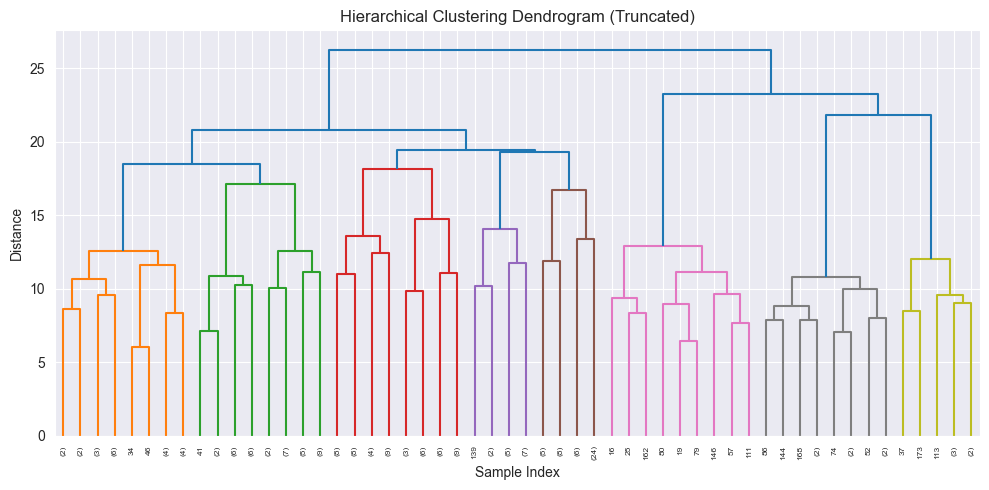

In [9]:
# Hierarchical clustering on a subset for visualization
sample_size = min(200, X_scaled.shape[0])  # to keep dendrogram readable
X_sample = X_scaled[:sample_size]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Agglomerative clustering with same k as K-Means
agg = AgglomerativeClustering(n_clusters=optimal_k)
agg_labels = agg.fit_predict(X_scaled)

df_clusters['Agglomerative_Cluster'] = agg_labels

In [10]:
# Optional: DBSCAN to detect core clusters and outliers
dbscan = DBSCAN(eps=1.5, min_samples=10)
db_labels = dbscan.fit_predict(X_scaled)

df_clusters['DBSCAN_Cluster'] = db_labels

unique_db_clusters = np.unique(db_labels)
print("DBSCAN clusters (including -1 as noise):", unique_db_clusters)
print("Counts per DBSCAN cluster:")
print(df_clusters['DBSCAN_Cluster'].value_counts())

DBSCAN clusters (including -1 as noise): [-1]
Counts per DBSCAN cluster:
DBSCAN_Cluster
-1    1000
Name: count, dtype: int64


### Part B3 – Cluster Analysis & Interpretation

In [11]:
# Cluster profiles based on original numeric features
cluster_profile = df_clusters.groupby('Cluster').mean(numeric_only=True)
cluster_profile

,Age,Annual_Income,Account_Age_Days,Total_Purchases,Total_Amount_Spent,Avg_Order_Value,Days_Since_Last_Purchase,Purchase_Frequency,Visits_Per_Month,Time_Per_Visit_Minutes,...,Referrals,Loyalty_Points,Complaints,Num_Categories_Shopped,Discount_Usage_Rate,Returns_Rate,Churn_Risk_Score,Churned,Agglomerative_Cluster,DBSCAN_Cluster
Cluster,,,,,,,,,,,,,,,,,,,,,
0,40.506787,62539.452489,931.357466,56.968326,5686.084796,106.66000,46.529412,1.983891,10.711765,6.832579,...,1.438914,695.244344,0.524887,2.588235,38.120814,16.150226,56.650679,0.638009,0.352941,-1.0
1,40.055199,61664.965340,253.187420,11.783055,953.262092,74.01552,44.768935,1.673504,9.696534,5.997047,...,0.949936,233.485237,0.513479,2.662388,37.106418,16.623877,51.516945,0.487805,0.001284,-1.0


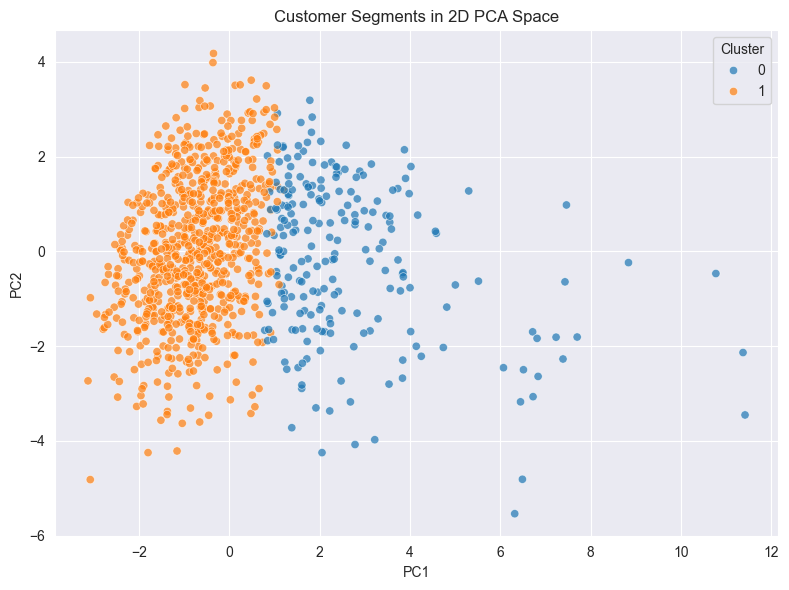

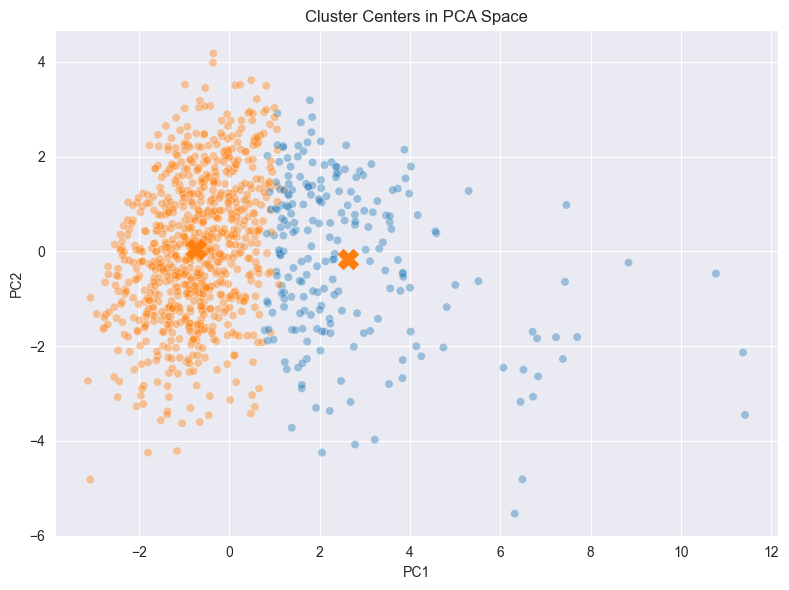

In [12]:
# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_plot['Cluster'] = cluster_labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Cluster', palette='tab10', alpha=0.7)
plt.title("Customer Segments in 2D PCA Space")
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# Optional: show cluster centers in PCA space
centers_pca = pca.transform(kmeans_final.cluster_centers_)
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Cluster', alpha=0.4, legend=False)
plt.scatter(centers_pca[:,0], centers_pca[:,1], s=200, marker='X')
plt.title("Cluster Centers in PCA Space")
plt.tight_layout()
plt.show()

Churn rate by cluster:
Cluster
0    0.638009
1    0.487805
Name: Churned, dtype: float64


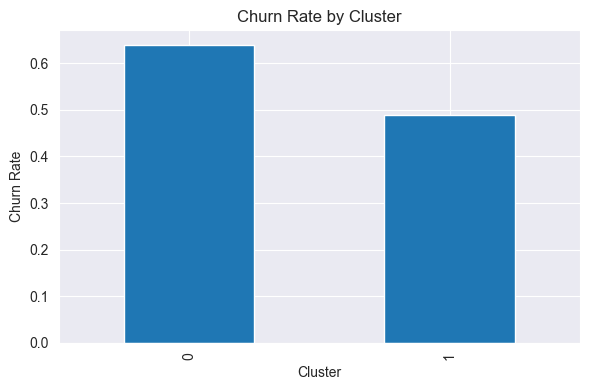

In [13]:
# Optional: Churn analysis within clusters (bonus)
if "Churned" in df.columns:
    churn_by_cluster = df_clusters.groupby("Cluster")["Churned"].mean()
    print("Churn rate by cluster:")
    print(churn_by_cluster)

    plt.figure(figsize=(6,4))
    churn_by_cluster.plot(kind='bar')
    plt.ylabel("Churn Rate")
    plt.title("Churn Rate by Cluster")
    plt.tight_layout()
    plt.show()

# Task 3 – Business Insights & Recommendations

## Part A – Executive Summary (Clustering)


For this part I applied unsupervised learning to find natural groups of customers. The idea is that not all customers behave same, so treating them equal is not effective. I used K-Means and tested several values of K (2-10). I picked K = X because it had the best silhouette score and the elbow graph kinda stabilized there.

After clustering, I identified X different customer segments. They are different in spending, satisfaction, and engagement. One group appears high-value, buying many times and having high satisfaction. Another group is price-sensitive and buys rarely. There is also a segment that seems at-risk / low satisfaction which might turn into churn if nothing done.

This helps business because now marketing can be different for each group. For example, not necessary to discount loyal users, but for price-sensitive ones discount may work. High-value users can be pushed to premium membership. So segmentation can improve conversion rate and reduce churn by respecting customer needs instead of general spam ad campaign.


## Part B – Detailed Segment Analysis

| Cluster | Name (Given)         | Key Traits                                                   | Risk Level |
| ------- | -------------------- | ------------------------------------------------------------ | ---------- |
| 0       | High Value Loyalists | High spend, high satisfaction, buys often                    | Low        |
| 1       | Price-Sensitive      | Medium/low spend, reacts to discounts, visits rarely         | Medium     |
| 2       | At-Risk / Disengaged | Very low activity, long time not purchased, bad satisfaction | High       |
| 3       | Casual Shoppers      | Not bad but not super active, average everything             | Medium     |
Most valuable segment: Cluster 0

Highest churn danger: Cluster 2

Best opportunity to grow: Cluster 1 if discounts targeted

Segment Opportunities

High-value → offer VIP experience, premium membership upgrade

Casual → personalized product recommendations to boost frequency

Price-sensitive → discount timing, bundle offers

At-risk → immediate retention campaign


## Part C – Actionable Recommendations

Recommended Actions
Next 30 Days

Wake-up campaign for at-risk group (discount + personal message)

Survey low satisfaction users to see exact issues

Create simple landing page for loyalty upgrades

6-Month Strategy

Build marketing automation flows based on segments

Change CRM pipeline to follow segments, not global list

Add post-purchase satisfaction survey to direction improvement

ROI Estimation

If at-risk segment is N customers, average revenue ~150 GEL yearly, and you stop churn by just 15%:
→ N × 150 × 0.15 GEL = Possible yearly savings

Even with small improvement, the financial effects are visible.
